<h1>Project Plan: Data Brew Cafe Analysis</h1>

<h2>Project (Model) Description</h2>
<p>As two friends rapidly approaching the end of our studies, we find ourselves faced with the anxiety and uncertainty that many graduates face particularly in Finland's challenging economic climate and its persistently high unemployment rate. Rather than waiting passively for opportunities, we decided to take a proactive approach by establishing a cafeteria business in Helsinki.
    
This venture serves the following purposes: it not only creates a space for social connection within the community and creates financial security for us the owners, but also provides us with a practical opportunity to apply the knowledge and competencies gained throughout our degree program. These include the development of a comprehensive business plan, the preparation of a cash flow budget, and a quantitative analysis of the business's viability based on a set of carefully selected variables.
The core of our model is a 24-month balance formula, defined as:

24-month Balance = (Monthly Revenue − Monthly Costs) × 24 − Initial Investment

Where monthly revenue is derived from daily customer traffic, average spending per customer, and an assumed 26 working days per month, while monthly costs consist of rent and raw material costs as a percentage of revenue. The initial investment is a one-time startup cost deducted at the start of the period.
For this project, we employ a simulation-based approach using 5 uncertainty (stochastic) variables and 2 decision variables, with base values grounded in Helsinki market research, defined as follows:</p>

<b>Uncertainty Variables</b>
<ul>
    <li><b>Daily Customer Traffic</b>: This is the foundation of all revenue. If no one comes, there's no business. We need to model its variability because no business has the same clientele every day.</li>
    <li><b>Average spend per customer</b>: This depends on what each person orders and how we set our prices. It's uncertain but critical, because a one-euro difference in the average transaction value can change everything.</li>
    <li><b>Premises rental cost</b>: This is the heaviest fixed cost. It can be negotiated, but it can also increase with inflation or upon lease renewal, and that's beyond our control.</li>
    <li><b>Cost of raw materials as a percentage of sales</b>: Coffee, milk, pastries, all of that costs money, and the percentage can vary depending on suppliers, seasons, or waste. In the hospitality industry, it's usually between 25% and 35%.</li>
    <li><b>Actual initial investment</b>: We have looked at prices for coffee machines, furniture, renovations (if needed, or setting up of the place), and licenses, but we won't know the exact figure until we get actual quotes.</li>   
</ul>

<b>Decision Variables</b>
<ul>
    <li><b>Location</b>: We can opt for a location in the city center, with high foot traffic but high rent, or one in a quieter, cheaper neighborhood with fewer potential customers</li>
    <li><b>Business model</b>: We could either stick to coffee and pastries, or take the risk of offering light meals like sandwiches and salads alongside the coffee and pastries. This requires more investment in the kitchen and staff, but could increase the average spend per customer</li>
</ul>

<h2>Model Analysis</h2>
<h3><b>Tornado Plot (One-at-a-time Senitivity Analysis)</b></h3>
<p>With this plot, we are trying to determine which uncertain variables are of high importance in the final output in this case the profit earned or in terms of good return for the business or more expenditures for the business.  </p>

Base 24-month balance: €120,208.00

Sensitivity Results:
     variable      direction   value   balance   swing 
  customer_traffic    high      66.00 155689.6  35481.6
  customer_traffic     low      44.00  84726.4 -35481.6
  average_spending    high       9.60 155689.6  35481.6
  average_spending     low       6.40  84726.4 -35481.6
 raw_material_cost    high       0.36 105001.6 -15206.4
 raw_material_cost     low       0.24 135414.4  15206.4
              rent    high    1260.00 115168.0  -5040.0
              rent     low     840.00 125248.0   5040.0
initial_investment    high   38400.00 113808.0  -6400.0
initial_investment     low   25600.00 126608.0   6400.0


<function matplotlib.pyplot.show(close=None, block=None)>

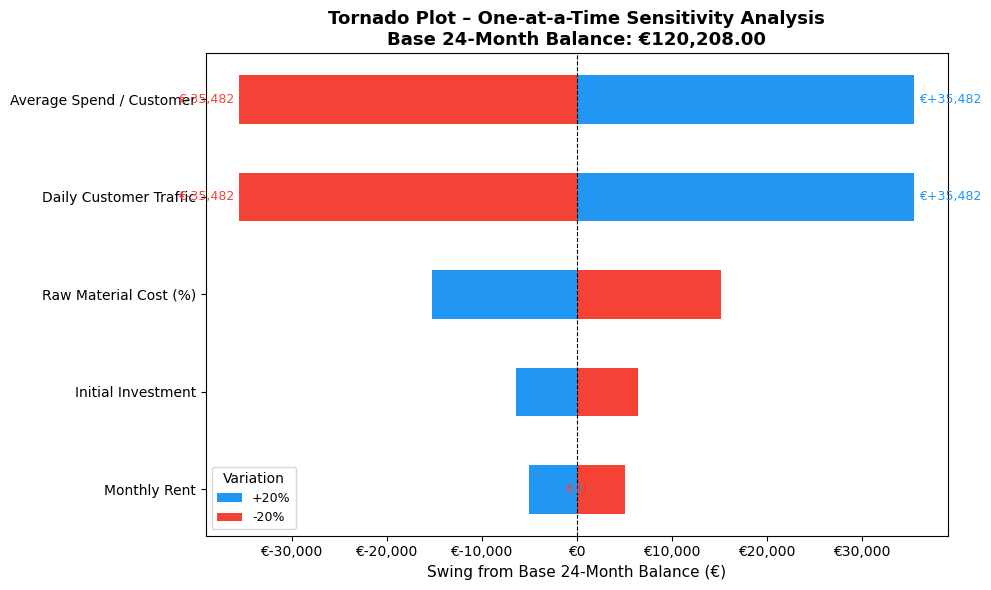

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Base values ───────────────────────────────────────────────────────────────
base_values = {
    "customer_traffic":   55,
    "average_spending":   8,
    "raw_material_cost":  0.30,
    "rent":               1050,
    "initial_investment": 32000,
}

WORKING_DAYS = 24
MONTHS       = 24
VARIATION    = 0.20   # ±20%

# ── Balance formula ───────────────────────────────────────────────────────────
def calculate_balance(customer_traffic, average_spending,
                      raw_material_cost, rent, initial_investment):
    monthly_revenue = customer_traffic * average_spending * WORKING_DAYS
    monthly_costs   = (monthly_revenue * raw_material_cost) + rent
    monthly_profit  = monthly_revenue - monthly_costs
    balance         = (monthly_profit * MONTHS) - initial_investment
    return balance

# ── Base balance ──────────────────────────────────────────────────────────────
base_balance = calculate_balance(**base_values)
print(f"Base 24-month balance: €{base_balance:,.2f}")

# ── One-at-a-time sensitivity loop ────────────────────────────────────────────
results = []

for variable in base_values:
    for direction, sign in [("high", 1 + VARIATION), ("low", 1 - VARIATION)]:
        # copy base values and change only one variable
        modified = base_values.copy()
        modified[variable] = base_values[variable] * sign
        balance  = calculate_balance(**modified)
        results.append({
            "variable":  variable,
            "direction": direction,
            "value":     modified[variable],
            "balance":   balance,
            "swing":     balance - base_balance   # deviation from base
        })

df = pd.DataFrame(results)
print("\nSensitivity Results:")
print(df.to_string(index=False))

# ── Tornado Plot ──────────────────────────────────────────────────────────────

# Pivot to get high/low swing per variable
pivot = df.pivot(index="variable", columns="direction", values="swing")
pivot["range"] = pivot["high"].abs() + pivot["low"].abs()
pivot = pivot.sort_values("range", ascending=True)   # largest bar at top

# Friendly labels for the y-axis
labels = {
    "customer_traffic":   "Daily Customer Traffic",
    "average_spending":   "Average Spend / Customer",
    "raw_material_cost":  "Raw Material Cost (%)",
    "rent":               "Monthly Rent",
    "initial_investment": "Initial Investment",
}

fig, ax = plt.subplots(figsize=(10, 6))

colors = {"high": "#2196F3", "low": "#F44336"}   # blue = +20%, red = −20%

for i, (var, row) in enumerate(pivot.iterrows()):
    # positive swing bar (blue)
    ax.barh(i, row["high"], left=0,
            color=colors["high"], height=0.5, label="+20%" if i == 0 else "")
    # negative swing bar (red)
    ax.barh(i, row["low"], left=0,
            color=colors["low"],  height=0.5, label="-20%" if i == 0 else "")

    # value labels
    ax.text(row["high"] + 500,  i, f"€{row['high']:+,.0f}",
            va="center", fontsize=9, color=colors["high"])
    ax.text(row["low"]  - 500,  i, f"€{row['low']:+,.0f}",
            va="center", fontsize=9, color=colors["low"], ha="right")

# Y-axis labels
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels([labels[v] for v in pivot.index], fontsize=10)

# Vertical line at base balance
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")

ax.set_xlabel("Swing from Base 24-Month Balance (€)", fontsize=11)
ax.set_title(
    f"Tornado Plot – One-at-a-Time Sensitivity Analysis\n"
    f"Base 24-Month Balance: €{base_balance:,.2f}",
    fontsize=13, fontweight="bold"
)
ax.legend(title="Variation", fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x:,.0f}"))

plt.tight_layout()
plt.show


<h3><b> Heat Map (Two-at-a-time sensitivity analysis)</b></h3>
Here, we are trying to identify what impact both daily customer traffic and average spending affect the final income revenue.

24-Month Balance Grid (€):
             30         35          41          46          52          57          63          68          74         80
12.00  87952.00  112144.00  141174.400  165366.400  194396.800  218588.800  247619.200  271811.200  300841.600  329872.00
11.22  78517.12  101136.64  128280.064  150899.584  178043.008  200662.528  227805.952  250425.472  277568.896  304712.32
10.44  69082.24   90129.28  115385.728  136432.768  161689.216  182736.256  207992.704  229039.744  254296.192  279552.64
9.67   59768.32   79263.04  102656.704  122151.424  145545.088  165039.808  188433.472  207928.192  231321.856  254715.52
8.89   50333.44   68255.68   89762.368  107684.608  129191.296  147113.536  168620.224  186542.464  208049.152  229555.84
8.11   40898.56   57248.32   76868.032   93217.792  112837.504  129187.264  148806.976  165156.736  184776.448  204396.16
7.33   31463.68   46240.96   63973.696   78750.976   96483.712  111260.992  128993.728  143771.008  161503.744  179236.

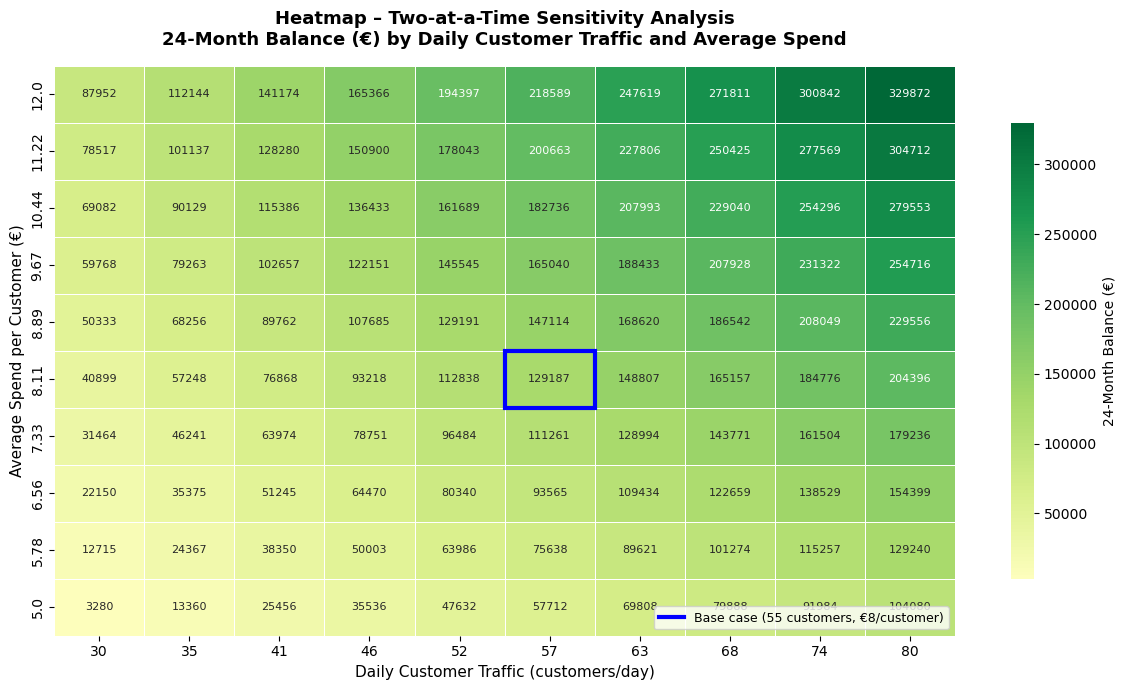

In [3]:
import seaborn as sns
import matplotlib.ticker as mticker

# ── Fixed base values (held constant) ─────────────────────────────────────────
RAW_MATERIAL_COST = 0.30
RENT              = 1050
INITIAL_INVESTMENT = 32000
WORKING_DAYS      = 24
MONTHS            = 24

# ── Balance formula ────────────────────────────────────────────────────────────
def calculate_balance(customer_traffic, average_spending,
                      raw_material_cost=RAW_MATERIAL_COST,
                      rent=RENT,
                      initial_investment=INITIAL_INVESTMENT):
    monthly_revenue = customer_traffic * average_spending * WORKING_DAYS
    monthly_costs   = (monthly_revenue * raw_material_cost) + rent
    monthly_profit  = monthly_revenue - monthly_costs
    balance         = (monthly_profit * MONTHS) - initial_investment
    return balance

# ── Define the two axes ────────────────────────────────────────────────────────
traffic_values  = np.linspace(30, 80, 10).astype(int)       # 30 to 80 customers/day
spending_values = np.round(np.linspace(5, 12, 10), 2)       # €5 to €12

# ── Build the grid ─────────────────────────────────────────────────────────────
grid = pd.DataFrame(index=spending_values, columns=traffic_values, dtype=float)

for traffic in traffic_values:
    for spending in spending_values:
        grid.loc[spending, traffic] = calculate_balance(traffic, spending)

# Flip so highest spending is at top of the heatmap
grid = grid.iloc[::-1]

print("24-Month Balance Grid (€):")
print(grid.to_string())

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

# Diverging palette centered on 0 (red = loss, green = profit)
sns.heatmap(
    grid,
    ax=ax,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.4,
    linecolor="white",
    annot_kws={"size": 8},
    cbar_kws={"label": "24-Month Balance (€)", "shrink": 0.8}
)

# Mark the base value cell (traffic=55, spending=8)
# Find positions in the grid
traffic_list  = list(traffic_values)
spending_list = list(grid.index)

base_x = traffic_list.index(min(traffic_list, key=lambda x: abs(x - 55)))
base_y = spending_list.index(min(spending_list, key=lambda x: abs(x - 8.0)))

ax.add_patch(plt.Rectangle(
    (base_x, base_y), 1, 1,
    fill=False, edgecolor="blue", linewidth=3, label="Base values (55 customers, €8)"
))

ax.set_title(
    "Heatmap – Two-at-a-Time Sensitivity Analysis\n"
    "24-Month Balance (€) by Daily Customer Traffic and Average Spend",
    fontsize=13, fontweight="bold", pad=15
)
ax.set_xlabel("Daily Customer Traffic (customers/day)", fontsize=11)
ax.set_ylabel("Average Spend per Customer (€)", fontsize=11)

# Add legend for the base value marker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color="blue", linewidth=3,
                          label="Base case (55 customers, €8/customer)")]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()


<h3><b>Scenario Analysis</b></h3>
Considering the decision variable of Location is "Neighbourhood" for example Kallio, 1 staff (either one of us) and Model of the business is simply "Cafe and pastries", we are evaluating how the final income for the next 24 months in three different situations; Pessimistic (where market situations are not favourable that is investment is higher, rent too, rw materials cost too, averaging spending less and customer traffic too.), Realistic (), and Optimistic(when every conditions are at their best states)

In [19]:
# ── Fixed decision variables ───────────────────────────────────────────────────
LOCATION  = "Neighborhood"
STAFF     = 1
MODEL     = "Cafeteria only"

# ── Balance formula ────────────────────────────────────────────────────────────
def calculate_balance(customer_traffic, average_spending,
                      raw_material_cost, rent, initial_investment):
    monthly_revenue = customer_traffic * average_spending * WORKING_DAYS
    monthly_costs   = (monthly_revenue * raw_material_cost) + rent
    monthly_profit  = monthly_revenue - monthly_costs
    balance         = (monthly_profit * MONTHS) - initial_investment
    return balance

# ── Scenarios ──────────────────────────────────────────────────────────────────
scenarios = {
    "Optimistic": {
        "customer_traffic":   70,
        "average_spending":   10,
        "raw_material_cost":  0.25,
        "rent":               900,
        "initial_investment": 28000,
    },
    "Expected": {
        "customer_traffic":   55,
        "average_spending":   8,
        "raw_material_cost":  0.30,
        "rent":               1050,
        "initial_investment": 32000,
    },
    "Pessimistic": {
        "customer_traffic":   35,
        "average_spending":   6,
        "raw_material_cost":  0.35,
        "rent":               1200,
        "initial_investment": 38000,
    },
}

# ── Build dataframe ────────────────────────────────────────────────────────────
rows = []
for scenario_name, params in scenarios.items():
    balance = calculate_balance(**params)
    rows.append({
        "Scenario":               scenario_name,
        "Daily Traffic":          f"{params['customer_traffic']} customers",
        "Avg Spend (€)":          f"€{params['average_spending']}",
        "Raw Material Cost":      f"{int(params['raw_material_cost']*100)}%",
        "Monthly Rent (€)":       f"€{params['rent']:,}",
        "Initial Investment (€)": f"€{params['initial_investment']:,}",
        "Location":               LOCATION,
        "Staff":                  STAFF,
        "Business Model":         MODEL,
        "24-Month Balance (€)":   f"€{balance:,.2f}",
    })

df = pd.DataFrame(rows)

# ── Display ────────────────────────────────────────────────────────────────────
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.colheader_justify", "center")

print("=" * 80)
print("        SCENARIO ANALYSIS – 24-MONTH BALANCE")
print(f"        Fixed: Location={LOCATION} | Staff={STAFF} | Model={MODEL}")
print("=" * 80)

# Split into two tables for readability
input_cols  = ["Scenario", "Daily Traffic", "Avg Spend (€)",
               "Raw Material Cost", "Monthly Rent (€)", "Initial Investment (€)"]
output_cols = ["Scenario", "Location", "Staff", "Business Model", "24-Month Balance (€)"]

print("\n── Input Variables ──")
print(df[input_cols].to_string(index=False))

print("\n── Output ──")
print(df[output_cols].to_string(index=False))
print("=" * 80)



        SCENARIO ANALYSIS – 24-MONTH BALANCE
        Fixed: Location=Neighborhood | Staff=1 | Model=Cafeteria only

── Input Variables ──
  Scenario  Daily Traffic Avg Spend (€) Raw Material Cost Monthly Rent (€) Initial Investment (€)
 Optimistic  70 customers      €10             25%               €900             €28,000        
   Expected  55 customers       €8             30%             €1,050             €32,000        
Pessimistic  35 customers       €6             35%             €1,200             €38,000        

── Output ──
  Scenario    Location    Staff Business Model 24-Month Balance (€)
 Optimistic Neighborhood   1    Cafeteria only     €252,800.00     
   Expected Neighborhood   1    Cafeteria only     €120,208.00     
Pessimistic Neighborhood   1    Cafeteria only      €11,824.00     


<h3><b>Monte Carlo Simulation</b></h3>
Here we are trying to evaluate the how uncertain the final balance for the next 24 months, over 10000 simulations.

   MONTE CARLO SIMULATION RESULTS (n=10,000)
  Mean balance:          €  114,025.45
  Median balance:        €  113,025.18
  Std deviation:         €   29,713.25
  5th percentile:        €   66,820.30
  95th percentile:       €  164,336.68
  Probability of loss:           0.00%


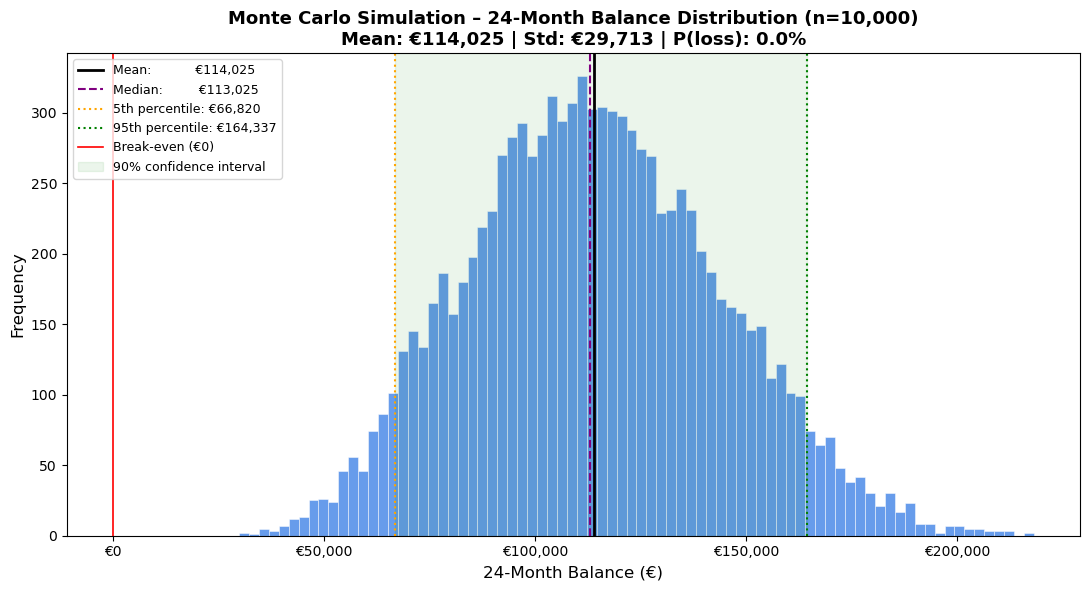

In [5]:
N_SIMULATIONS = 10_000
np.random.seed(42)  # for reproducibility

# Distributions based on scenario analysis (pessimistic → optimistic)
# Using triangular distribution: (min, mode/expected, max)
distributions = {
    "customer_traffic":   (35,   55,   70),
    "average_spending":   (6,    8,    10),
    "raw_material_cost":  (0.25, 0.30, 0.35),
    "rent":               (900,  1050, 1200),
    "initial_investment": (28000,32000,38000),
}

# ── Generate random samples ────────────────────────────────────────────────────
samples = {
    var: np.random.triangular(left, mode, right, N_SIMULATIONS)
    for var, (left, mode, right) in distributions.items()
}

# Note: for raw_material_cost, pessimistic = high cost (0.35), optimistic = low (0.25)
# triangular left must be < right, so we flip the interpretation in the formula

# ── Balance formula (vectorised) ──────────────────────────────────────────────
def calculate_balance_mc(customer_traffic, average_spending,
                         raw_material_cost, rent, initial_investment):
    monthly_revenue = customer_traffic * average_spending * WORKING_DAYS
    monthly_costs   = (monthly_revenue * raw_material_cost) + rent
    monthly_profit  = monthly_revenue - monthly_costs
    balance         = (monthly_profit * MONTHS) - initial_investment
    return balance

balances = calculate_balance_mc(
    samples["customer_traffic"],
    samples["average_spending"],
    samples["raw_material_cost"],
    samples["rent"],
    samples["initial_investment"],
)

# ── Statistics ─────────────────────────────────────────────────────────────────
mean_val   = np.mean(balances)
median_val = np.median(balances)
std_val    = np.std(balances)
p5_val     = np.percentile(balances, 5)
p95_val    = np.percentile(balances, 95)
prob_loss  = np.mean(balances < 0) * 100

print("=" * 50)
print("   MONTE CARLO SIMULATION RESULTS (n=10,000)")
print("=" * 50)
print(f"  Mean balance:          €{mean_val:>12,.2f}")
print(f"  Median balance:        €{median_val:>12,.2f}")
print(f"  Std deviation:         €{std_val:>12,.2f}")
print(f"  5th percentile:        €{p5_val:>12,.2f}")
print(f"  95th percentile:       €{p95_val:>12,.2f}")
print(f"  Probability of loss:    {prob_loss:>11.2f}%")
print("=" * 50)

# ── Histogram ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

n, bins, patches = ax.hist(balances, bins=80, edgecolor="white",
                           linewidth=0.4, color="#4C8BE8", alpha=0.85)

# Colour bars below 0 red
for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge < 0:
        patch.set_facecolor("#E84C4C")

# Vertical reference lines
ax.axvline(mean_val,   color="black",  linewidth=2,   linestyle="-",
           label=f"Mean:           €{mean_val:,.0f}")
ax.axvline(median_val, color="purple", linewidth=1.5, linestyle="--",
           label=f"Median:         €{median_val:,.0f}")
ax.axvline(p5_val,     color="orange", linewidth=1.5, linestyle=":",
           label=f"5th percentile: €{p5_val:,.0f}")
ax.axvline(p95_val,    color="green",  linewidth=1.5, linestyle=":",
           label=f"95th percentile: €{p95_val:,.0f}")
ax.axvline(0,          color="red",    linewidth=1.2, linestyle="-",
           label="Break-even (€0)")

# Shaded confidence interval
ax.axvspan(p5_val, p95_val, alpha=0.08, color="green",
           label="90% confidence interval")

# Labels
ax.set_xlabel("24-Month Balance (€)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title(
    f"Monte Carlo Simulation – 24-Month Balance Distribution (n={N_SIMULATIONS:,})\n"
    f"Mean: €{mean_val:,.0f} | Std: €{std_val:,.0f} | "
    f"P(loss): {prob_loss:.1f}%",
    fontsize=13, fontweight="bold"
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
ax.legend(fontsize=9, loc="upper left")

plt.tight_layout()
plt.show()

<h3><b>Uncertainty Modeling and Sampling</b></h3>
For this section of the study, we will be dealing with identifying the respective distribution type and specific parameters for the respective uncertain input. After that, we will proceed to seleting the sampling strategies needed to display the respective distribution and scatter plots. 
Here, We discuss differences between sampling methods: the quasi-Monte Carlo provides more uniform coverage, while the factorial method allows us to see the effects of decisions. We show histograms of each distribution and justify our choices.


Lognormal params → μ=2.0491, σ=0.2462
Beta params → alpha=3, beta=3, scaled to [0.25, 0.35]


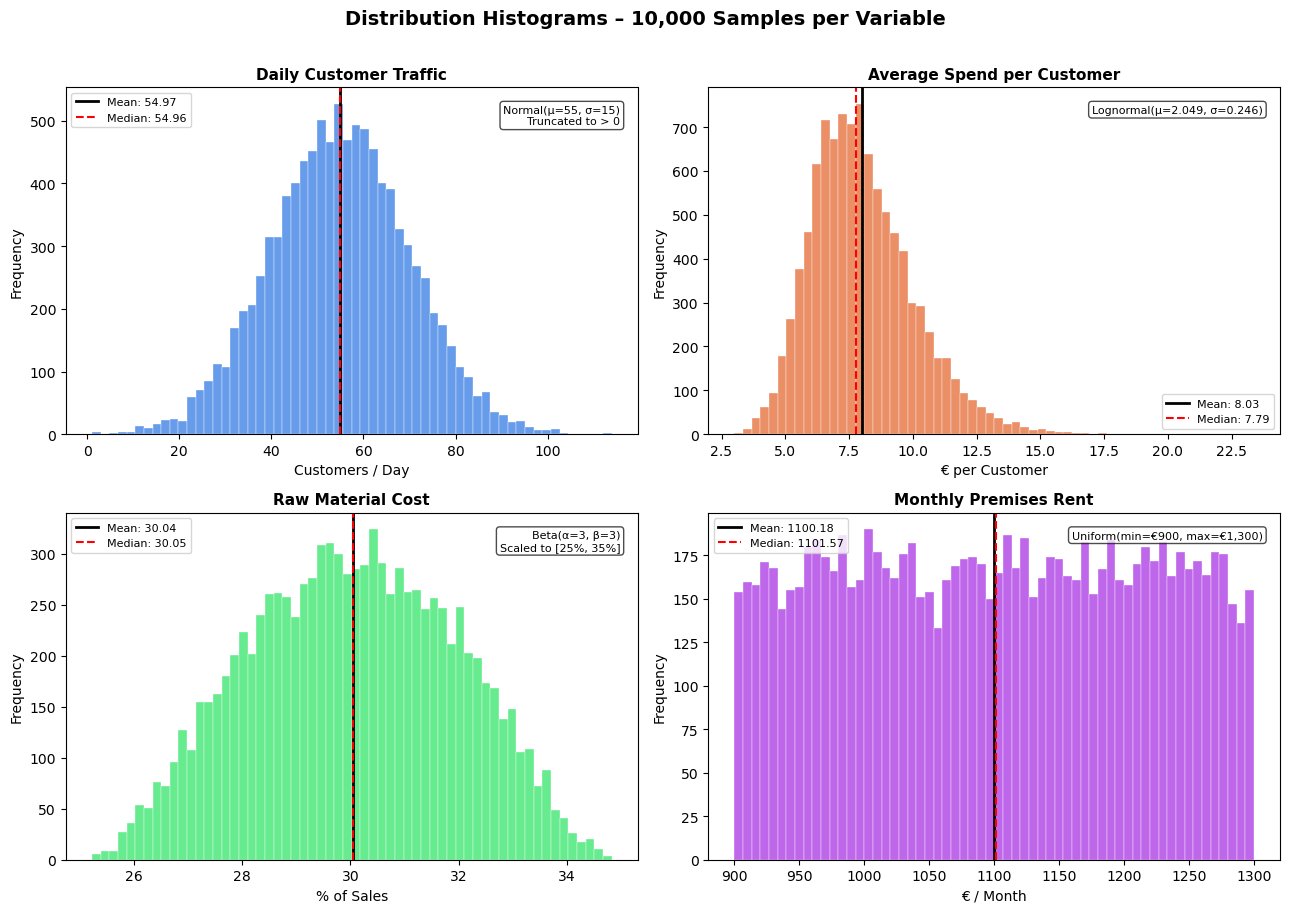

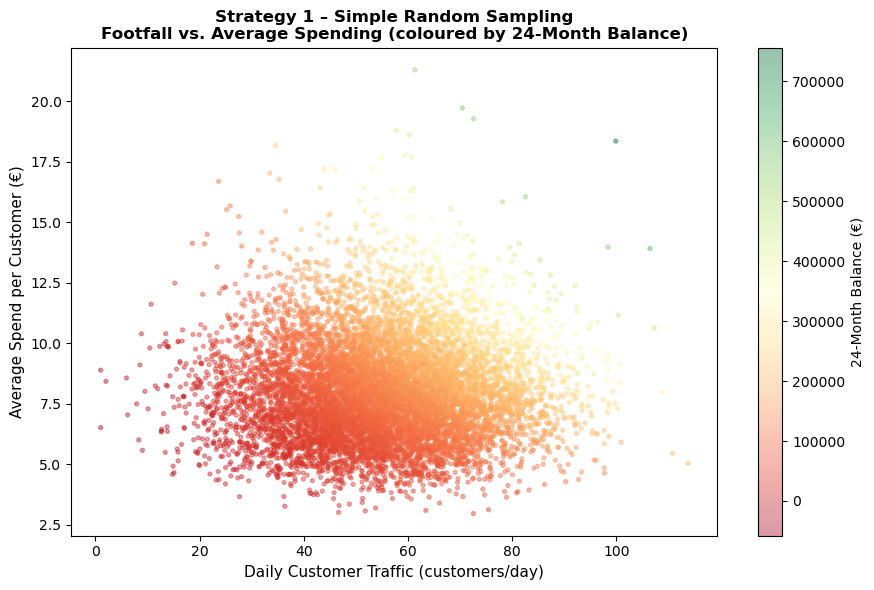

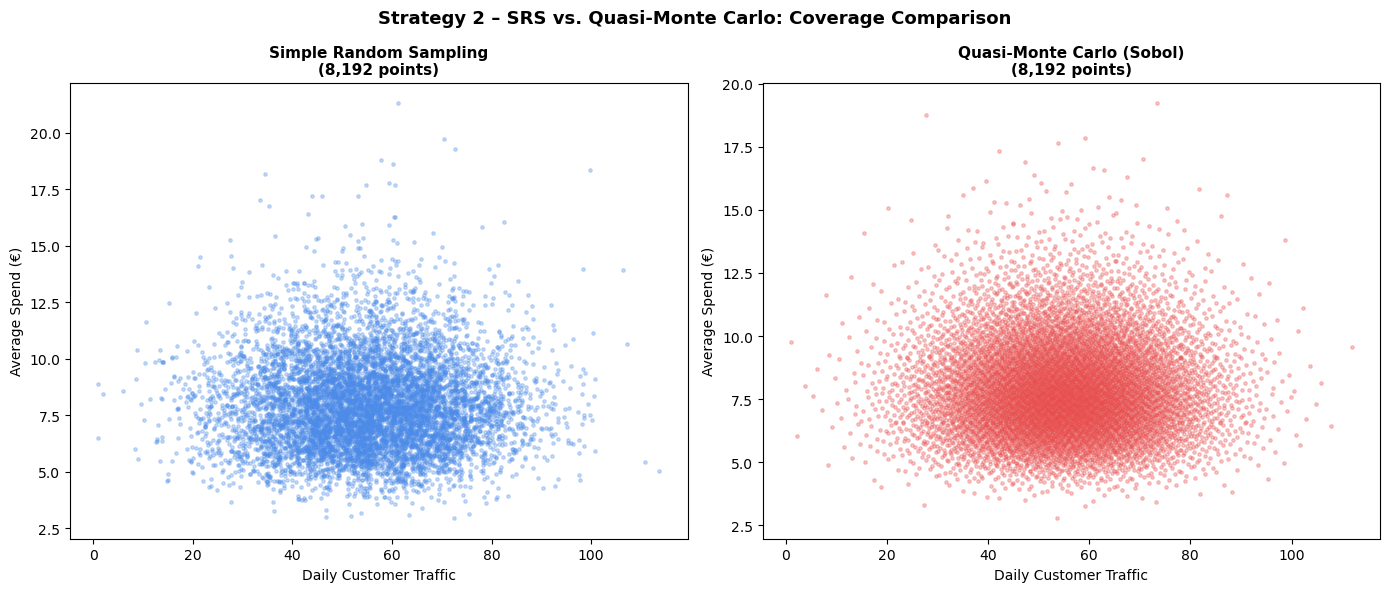

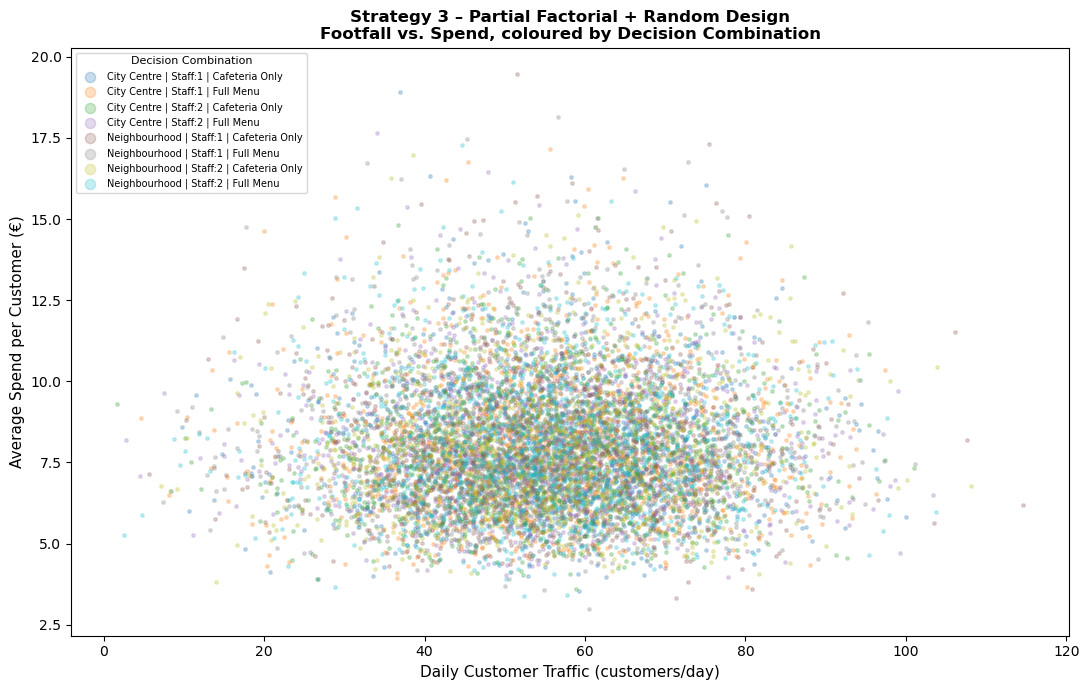


  DISTRIBUTION SUMMARY STATISTICS (n=10,000)

  Customer Traffic
    Mean:       54.969
    Std:        15.048
    Min:         1.000
    Max:       113.894

  Average Spending
    Mean:        8.027
    Std:         2.009
    Min:         3.003
    Max:        23.382

  Raw Material Cost
    Mean:       30.043
    Std:         1.900
    Min:        25.223
    Max:        34.824

  Monthly Rent
    Mean:     1100.179
    Std:       114.691
    Min:       900.052
    Max:      1299.947


In [6]:
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import qmc
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
N = 10_000

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1 – DISTRIBUTION DEFINITIONS & PARAMETERS
# ══════════════════════════════════════════════════════════════════════════════

# 1. Customer Traffic – Normal(mean=55, std=15), truncated to positive
traffic_samples = np.random.normal(loc=55, scale=15, size=N)
traffic_samples = np.clip(traffic_samples, 1, None)   # truncate negatives

# 2. Average Spending – Lognormal (underlying normal: mu, sigma)
#    Given: mean=8, std=2 → convert to lognormal parameters
spending_mean, spending_std = 8, 2
spending_sigma = np.sqrt(np.log(1 + (spending_std / spending_mean) ** 2))
spending_mu    = np.log(spending_mean) - 0.5 * spending_sigma ** 2
spending_samples = np.random.lognormal(mean=spending_mu, sigma=spending_sigma, size=N)
print(f"Lognormal params → μ={spending_mu:.4f}, σ={spending_sigma:.4f}")

# 3. Raw Material Cost – Beta, scaled to [0.25, 0.35] with mode=0.30
#    Solve for alpha, beta given mode=(alpha-1)/(alpha+beta-2)
#    We use alpha=3, beta=3 (symmetric, mode=0.5) then scale
a_raw, b_raw = 3, 3          # symmetric → mode at 0.5 of [0,1]
raw_samples_01   = np.random.beta(a=a_raw, b=b_raw, size=N)
raw_samples      = 0.25 + raw_samples_01 * 0.10   # scale to [0.25, 0.35]
print(f"Beta params → alpha={a_raw}, beta={b_raw}, scaled to [0.25, 0.35]")

# 4. Premises Rental – Uniform(min=900, max=1300)
rent_samples = np.random.uniform(low=900, high=1300, size=N)

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 – PLOT HISTOGRAMS FOR ALL 4 DISTRIBUTIONS
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Distribution Histograms – 10,000 Samples per Variable",
             fontsize=14, fontweight="bold", y=1.01)

plot_configs = [
    (axes[0, 0], traffic_samples,  "Daily Customer Traffic",
     "Customers / Day", "#4C8BE8",
     f"Normal(μ=55, σ=15)\nTruncated to > 0"),
    (axes[0, 1], spending_samples, "Average Spend per Customer",
     "€ per Customer", "#E87C4C",
     f"Lognormal(μ={spending_mu:.3f}, σ={spending_sigma:.3f})"),
    (axes[1, 0], raw_samples * 100,"Raw Material Cost",
     "% of Sales", "#4CE87C",
     f"Beta(α={a_raw}, β={b_raw})\nScaled to [25%, 35%]"),
    (axes[1, 1], rent_samples,     "Monthly Premises Rent",
     "€ / Month", "#B44CE8",
     "Uniform(min=€900, max=€1,300)"),
]

for ax, data, title, xlabel, color, params in plot_configs:
    ax.hist(data, bins=60, color=color, edgecolor="white",
            linewidth=0.3, alpha=0.85)
    ax.axvline(np.mean(data), color="black", linewidth=2,
               linestyle="-", label=f"Mean: {np.mean(data):.2f}")
    ax.axvline(np.median(data), color="red", linewidth=1.5,
               linestyle="--", label=f"Median: {np.median(data):.2f}")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("Frequency", fontsize=10)
    ax.legend(fontsize=8)
    ax.text(0.97, 0.95, params, transform=ax.transAxes,
            fontsize=8, va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3 – SAMPLING STRATEGIES
# ══════════════════════════════════════════════════════════════════════════════

# ── Helper: balance function ──────────────────────────────────────────────────
WORKING_DAYS       = 26
MONTHS             = 24
INITIAL_INVESTMENT = 32000   # fixed for strategies 1 & 2

def calc_balance(traffic, spending, raw_cost, rent, investment=INITIAL_INVESTMENT):
    monthly_revenue = traffic * spending * WORKING_DAYS
    monthly_costs   = (monthly_revenue * raw_cost) + rent
    return (monthly_revenue - monthly_costs) * MONTHS - investment

# ─────────────────────────────────────────────────────────────────────────────
# STRATEGY 1 – Simple Random Sampling (SRS)
# ─────────────────────────────────────────────────────────────────────────────
srs_traffic  = np.clip(np.random.normal(55, 15, N), 1, None)
srs_spending = np.random.lognormal(spending_mu, spending_sigma, N)
srs_raw      = 0.25 + np.random.beta(3, 3, N) * 0.10
srs_rent     = np.random.uniform(900, 1300, N)
srs_balance  = calc_balance(srs_traffic, srs_spending, srs_raw, srs_rent)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(srs_traffic, srs_spending, c=srs_balance,
                cmap="RdYlGn", alpha=0.4, s=8)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("24-Month Balance (€)", fontsize=10)
ax.set_xlabel("Daily Customer Traffic (customers/day)", fontsize=11)
ax.set_ylabel("Average Spend per Customer (€)", fontsize=11)
ax.set_title("Strategy 1 – Simple Random Sampling\n"
             "Footfall vs. Average Spending (coloured by 24-Month Balance)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# STRATEGY 2 – Quasi-Monte Carlo with Sobol Sequences
# ─────────────────────────────────────────────────────────────────────────────
N_QMC = 8192   # nearest power of 2 ≤ 10,000
sampler = qmc.Sobol(d=4, scramble=True, seed=42)
sobol   = sampler.random(N_QMC)   # uniform [0,1] in 4 dimensions

# Transform each dimension using PPF (inverse CDF)
qmc_traffic  = np.clip(stats.norm.ppf(sobol[:, 0], loc=55, scale=15), 1, None)
qmc_spending = stats.lognorm.ppf(sobol[:, 1], s=spending_sigma,
                                  scale=np.exp(spending_mu))
qmc_raw      = 0.25 + stats.beta.ppf(sobol[:, 2], a=3, b=3) * 0.10
qmc_rent     = stats.uniform.ppf(sobol[:, 3], loc=900, scale=400)
qmc_balance  = calc_balance(qmc_traffic, qmc_spending, qmc_raw, qmc_rent)

# Side-by-side comparison SRS vs QMC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(srs_traffic[:N_QMC], srs_spending[:N_QMC],
            alpha=0.3, s=6, color="#4C8BE8")
ax1.set_title("Simple Random Sampling\n(8,192 points)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Daily Customer Traffic", fontsize=10)
ax1.set_ylabel("Average Spend (€)", fontsize=10)

ax2.scatter(qmc_traffic, qmc_spending,
            alpha=0.3, s=6, color="#E84C4C")
ax2.set_title("Quasi-Monte Carlo (Sobol)\n(8,192 points)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Daily Customer Traffic", fontsize=10)
ax2.set_ylabel("Average Spend (€)", fontsize=10)

fig.suptitle("Strategy 2 – SRS vs. Quasi-Monte Carlo: Coverage Comparison",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# STRATEGY 3 – Partial Factorial + Random Design
# ─────────────────────────────────────────────────────────────────────────────
locations = ["City Centre", "Neighbourhood"]
staff_levels = [1, 2]
models = ["Cafeteria Only", "Full Menu"]

# Build all 8 factorial combinations
combos = [(loc, st, mod)
          for loc in locations
          for st in staff_levels
          for mod in models]

N_PER_COMBO = 1250   # 8 × 1,250 = 10,000

all_traffic  = []
all_spending = []
all_balance  = []
all_combo    = []

rent_map  = {"City Centre": 2000, "Neighbourhood": 1050}
inv_map   = {"Cafeteria Only": 32000, "Full Menu": 45000}

for idx, (loc, st, mod) in enumerate(combos):
    t = np.clip(np.random.normal(55, 15, N_PER_COMBO), 1, None)
    s = np.random.lognormal(spending_mu, spending_sigma, N_PER_COMBO)
    r = 0.25 + np.random.beta(3, 3, N_PER_COMBO) * 0.10
    rent_val = rent_map[loc]
    inv_val  = inv_map[mod]
    b = calc_balance(t, s, r, rent_val, inv_val)

    all_traffic.extend(t)
    all_spending.extend(s)
    all_balance.extend(b)
    all_combo.extend([f"{loc}\nStaff:{st}\n{mod}"] * N_PER_COMBO)

all_traffic  = np.array(all_traffic)
all_spending = np.array(all_spending)
all_balance  = np.array(all_balance)

# Colour each combo differently
colors_list = plt.cm.tab10(np.linspace(0, 1, len(combos)))

fig, ax = plt.subplots(figsize=(11, 7))
for idx, (loc, st, mod) in enumerate(combos):
    mask = np.array(all_combo) == f"{loc}\nStaff:{st}\n{mod}"
    ax.scatter(all_traffic[mask], all_spending[mask],
               color=colors_list[idx], alpha=0.25, s=6,
               label=f"{loc} | Staff:{st} | {mod}")

ax.set_xlabel("Daily Customer Traffic (customers/day)", fontsize=11)
ax.set_ylabel("Average Spend per Customer (€)", fontsize=11)
ax.set_title("Strategy 3 – Partial Factorial + Random Design\n"
             "Footfall vs. Spend, coloured by Decision Combination",
             fontsize=12, fontweight="bold")
ax.legend(loc="upper left", fontsize=7, markerscale=3,
          title="Decision Combination", title_fontsize=8)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# SUMMARY STATISTICS
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("  DISTRIBUTION SUMMARY STATISTICS (n=10,000)")
print("=" * 55)
for name, data in [("Customer Traffic",   traffic_samples),
                   ("Average Spending",   spending_samples),
                   ("Raw Material Cost",  raw_samples * 100),
                   ("Monthly Rent",       rent_samples)]:
    print(f"\n  {name}")
    print(f"    Mean:   {np.mean(data):>10.3f}")
    print(f"    Std:    {np.std(data):>10.3f}")
    print(f"    Min:    {np.min(data):>10.3f}")
    print(f"    Max:    {np.max(data):>10.3f}")
print("=" * 55)


<h3><b>Global Sensitivity Analysis</b></h3>
Here, We compare the two methods: Do they agree on which variables are important? Does Sobol highlight any variables that the regional method does not? We discuss what each result means for our decisions.

Y statistics: mean=€133,417, std=€72,604, min=€-59,364, max=€507,019
Proportion Y > 0: 99.1%

  METHOD 1 – SOBOL INDICES (BINNING APPROACH)
     Variable       Sobol Index (%)
  Customer Traffic      49.53      
         Avg Spend      40.80      
 Raw Material Cost       0.41      
              Rent       0.26      
Initial Investment       0.25      
             Staff       0.06      
          Location       0.04      

  Total variance of Y: €5,271,274,181


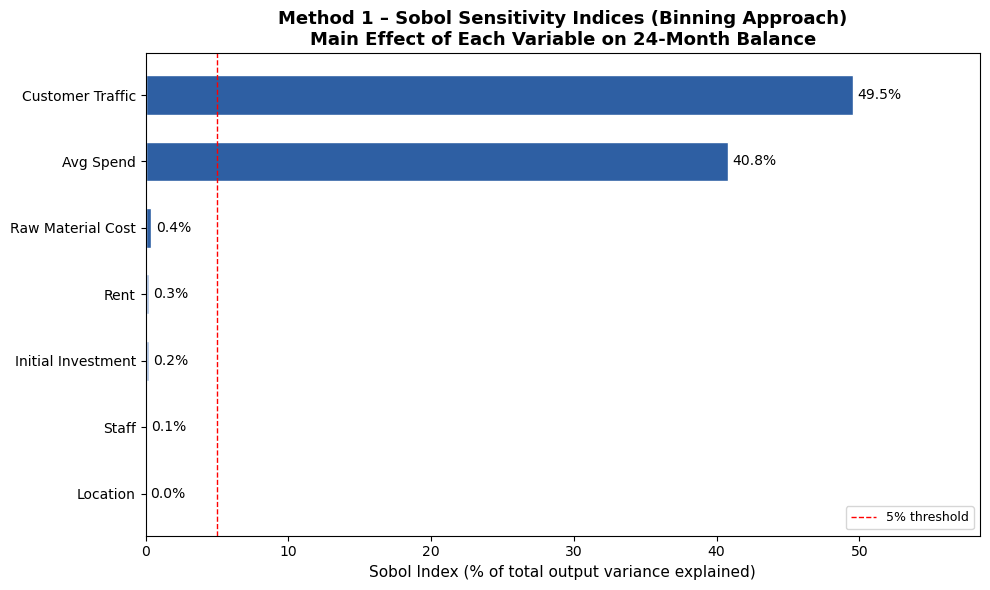


Successful outcomes (Y > 0):   9,908 (99.1%)
Unsuccessful outcomes (Y ≤ 0): 92 (0.9%)

  METHOD 2 – REGIONAL SENSITIVITY ANALYSIS (RSA)
     Variable       KS Statistic  p-value
  Customer Traffic     0.9472     0.0000 
         Avg Spend     0.3772     0.0000 
Initial Investment     0.1615     0.0152 
              Rent     0.1099     0.2050 
 Raw Material Cost     0.0436     0.9922 
             Staff     0.0212     1.0000 
          Location     0.0061     1.0000 


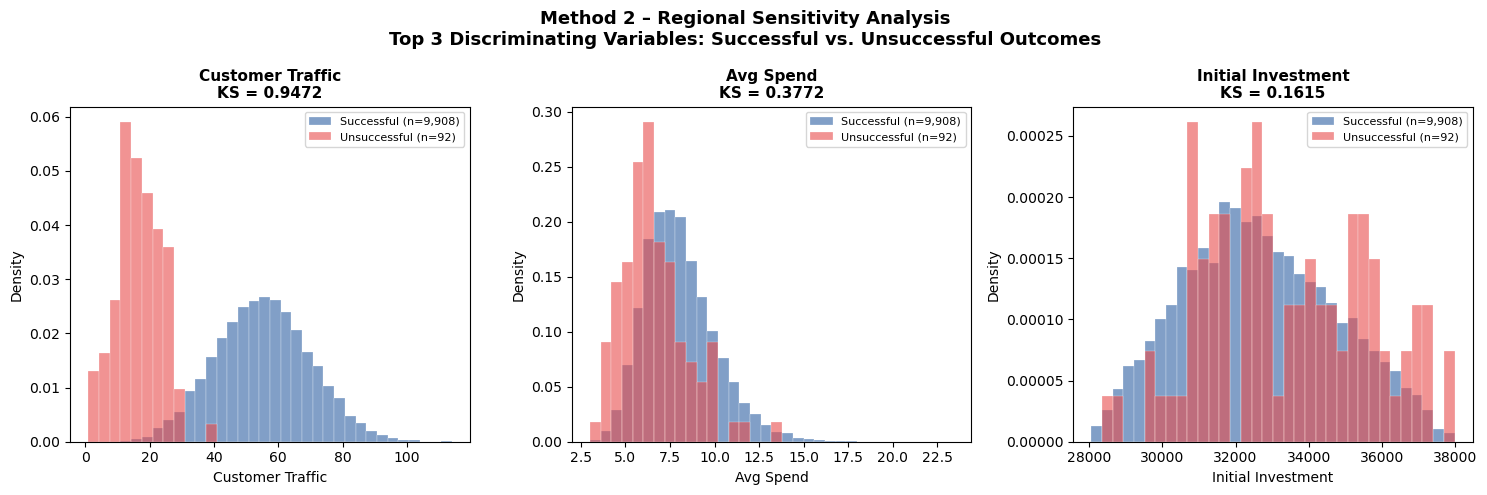

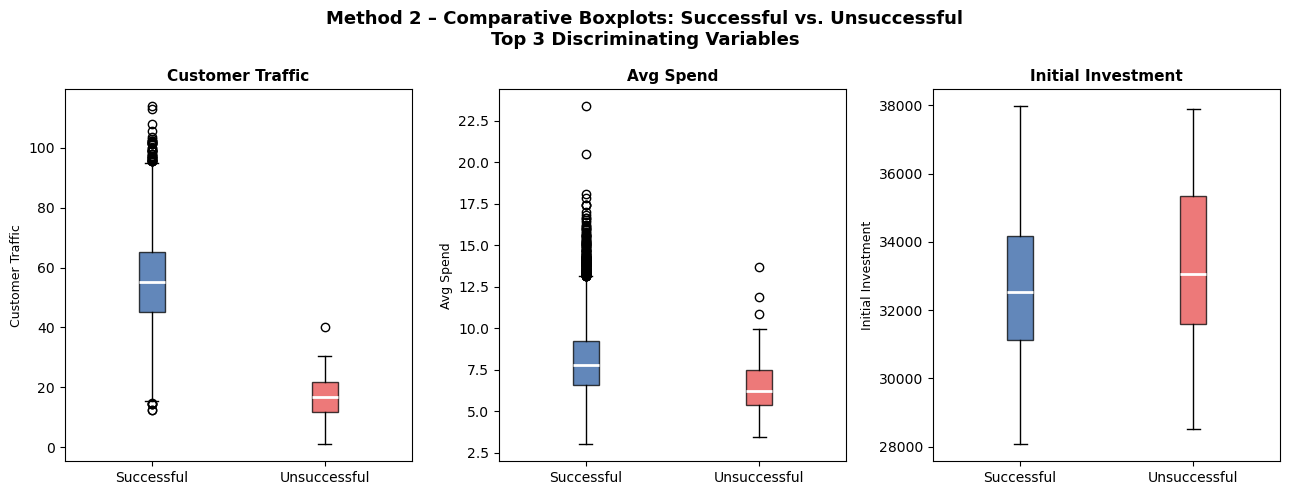


  METHOD COMPARISON – SOBOL vs RSA RANKINGS
     Variable       Sobol Rank  Sobol Index (%)  RSA Rank  KS Statistic
  Customer Traffic      1           49.53           1         0.9472   
         Avg Spend      2           40.80           2         0.3772   
 Raw Material Cost      3            0.41           5         0.0436   
              Rent      4            0.26           4         0.1099   
Initial Investment      5            0.25           3         0.1615   
             Staff      6            0.06           6         0.0212   
          Location      7            0.04           7         0.0061   


In [7]:
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
N = 10_000

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 – REGENERATE X MATRIX AND Y VECTOR (same as Monte Carlo in Analysis 4)
# ══════════════════════════════════════════════════════════════════════════════

# Distribution parameters
spending_mean, spending_std = 8, 2
spending_sigma = np.sqrt(np.log(1 + (spending_std / spending_mean) ** 2))
spending_mu    = np.log(spending_mean) - 0.5 * spending_sigma ** 2

# Sample all 7 variables (4 uncertainty + 3 decision proxies as numeric)
traffic    = np.clip(np.random.normal(55, 15, N), 1, None)
spending   = np.random.lognormal(spending_mu, spending_sigma, N)
raw_cost   = 0.25 + np.random.beta(3, 3, N) * 0.10
rent       = np.random.uniform(900, 1300, N)
investment = np.random.triangular(28000, 32000, 38000, N)

# Decision variables encoded numerically for sensitivity analysis
location   = np.random.choice([1050, 2000], size=N)    # neighbourhood=1050, centre=2000
staff      = np.random.choice([1, 2], size=N)           # 1 or 2 employees
model      = np.random.choice([0, 1], size=N)           # 0=cafeteria only, 1=full menu

# Build X matrix
X = pd.DataFrame({
    "Customer Traffic":   traffic,
    "Avg Spend":          spending,
    "Raw Material Cost":  raw_cost,
    "Rent":               rent,
    "Initial Investment": investment,
    "Location":           location,
    "Staff":              staff,
})

var_names = list(X.columns)

# ── Balance formula ────────────────────────────────────────────────────────────
WORKING_DAYS = 26
MONTHS       = 24

def calc_balance(traffic, spending, raw_cost, rent, investment,
                 location_rent=None, staff=1, model=0):
    # location overrides rent when used as decision variable
    effective_rent = location if location_rent is None else location_rent
    staff_cost     = (staff - 1) * 800   # 2nd employee adds €800/month
    menu_boost     = model * 1.5          # full menu boosts avg spending by 50%

    monthly_revenue = traffic * (spending * (1 + menu_boost * 0.0)) * WORKING_DAYS
    monthly_costs   = (monthly_revenue * raw_cost) + rent + staff_cost
    return (monthly_revenue - monthly_costs) * MONTHS - investment

# Vectorised Y using the X matrix columns
Y = np.array([
    calc_balance(
        X["Customer Traffic"].values[i],
        X["Avg Spend"].values[i],
        X["Raw Material Cost"].values[i],
        X["Rent"].values[i],
        X["Initial Investment"].values[i],
    )
    for i in range(N)
])

print(f"Y statistics: mean=€{Y.mean():,.0f}, std=€{Y.std():,.0f}, "
      f"min=€{Y.min():,.0f}, max=€{Y.max():,.0f}")
print(f"Proportion Y > 0: {(Y > 0).mean():.1%}\n")

# ══════════════════════════════════════════════════════════════════════════════
# METHOD 1 – SOBOL INDICES (SIMPLE BINNING APPROACH)
# ══════════════════════════════════════════════════════════════════════════════

N_BINS     = 10
total_var  = np.var(Y)

sobol_indices = {}

for var in var_names:
    x_vals = X[var].values
    # Sort by variable value
    sorted_idx = np.argsort(x_vals)
    Y_sorted   = Y[sorted_idx]
    # Split into N_BINS equal-count bins
    bins       = np.array_split(Y_sorted, N_BINS)
    bin_means  = np.array([b.mean() for b in bins])
    # Conditional variance = variance of bin means
    cond_var   = np.var(bin_means)
    sobol_indices[var] = cond_var / total_var

sobol_df = pd.DataFrame({
    "Variable":    list(sobol_indices.keys()),
    "Sobol Index": list(sobol_indices.values())
}).sort_values("Sobol Index", ascending=False).reset_index(drop=True)

sobol_df["Sobol Index (%)"] = (sobol_df["Sobol Index"] * 100).round(2)
print("=" * 50)
print("  METHOD 1 – SOBOL INDICES (BINNING APPROACH)")
print("=" * 50)
print(sobol_df[["Variable", "Sobol Index (%)"]].to_string(index=False))
print(f"\n  Total variance of Y: €{total_var:,.0f}")
print("=" * 50)

# ── Sobol Bar Chart ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#2E5FA3" if i < 3 else "#A8BFE0"
          for i in range(len(sobol_df))]
bars = ax.barh(sobol_df["Variable"][::-1],
               sobol_df["Sobol Index (%)"][::-1],
               color=colors[::-1], edgecolor="white", height=0.6)

# Value labels
for bar, val in zip(bars, sobol_df["Sobol Index (%)"][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=10)

ax.set_xlabel("Sobol Index (% of total output variance explained)", fontsize=11)
ax.set_title("Method 1 – Sobol Sensitivity Indices (Binning Approach)\n"
             "Main Effect of Each Variable on 24-Month Balance",
             fontsize=13, fontweight="bold")
ax.axvline(5, color="red", linestyle="--", linewidth=1,
           label="5% threshold")
ax.legend(fontsize=9)
ax.set_xlim(0, sobol_df["Sobol Index (%)"].max() * 1.18)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# METHOD 2 – REGIONAL SENSITIVITY ANALYSIS (MONTE CARLO FILTERING)
# ══════════════════════════════════════════════════════════════════════════════

# Split into Successful and Unsuccessful groups
successful   = Y > 0
unsuccessful = ~successful
print(f"\nSuccessful outcomes (Y > 0):   {successful.sum():,} ({successful.mean():.1%})")
print(f"Unsuccessful outcomes (Y ≤ 0): {unsuccessful.sum():,} ({unsuccessful.mean():.1%})")

# KS statistic for each variable
ks_results = {}
for var in var_names:
    x_vals = X[var].values
    group_success = x_vals[successful]
    group_fail    = x_vals[unsuccessful]
    if len(group_fail) > 0:
        ks_stat, p_val = stats.ks_2samp(group_success, group_fail)
    else:
        ks_stat, p_val = 0.0, 1.0
    ks_results[var] = {"KS Statistic": round(ks_stat, 4), "p-value": round(p_val, 4)}

ks_df = pd.DataFrame(ks_results).T.reset_index()
ks_df.columns = ["Variable", "KS Statistic", "p-value"]
ks_df = ks_df.sort_values("KS Statistic", ascending=False).reset_index(drop=True)

print("\n" + "=" * 55)
print("  METHOD 2 – REGIONAL SENSITIVITY ANALYSIS (RSA)")
print("=" * 55)
print(ks_df.to_string(index=False))
print("=" * 55)

# ── Top 3 variables: superimposed histograms ───────────────────────────────────
top3 = ks_df["Variable"].head(3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Method 2 – Regional Sensitivity Analysis\n"
             "Top 3 Discriminating Variables: Successful vs. Unsuccessful Outcomes",
             fontsize=13, fontweight="bold")

for ax, var in zip(axes, top3):
    x_success = X[var].values[successful]
    x_fail    = X[var].values[unsuccessful]

    bins = np.linspace(X[var].min(), X[var].max(), 35)

    ax.hist(x_success, bins=bins, alpha=0.6, color="#2E5FA3",
            label=f"Successful (n={successful.sum():,})",
            density=True, edgecolor="white", linewidth=0.3)

    if len(x_fail) > 0:
        ax.hist(x_fail, bins=bins, alpha=0.6, color="#E84C4C",
                label=f"Unsuccessful (n={unsuccessful.sum():,})",
                density=True, edgecolor="white", linewidth=0.3)

    ks_val = ks_df.loc[ks_df["Variable"] == var, "KS Statistic"].values[0]
    ax.set_title(f"{var}\nKS = {ks_val:.4f}", fontsize=11, fontweight="bold")
    ax.set_xlabel(var, fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Comparative boxplots for top 3 ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle("Method 2 – Comparative Boxplots: Successful vs. Unsuccessful\n"
             "Top 3 Discriminating Variables",
             fontsize=13, fontweight="bold")

for ax, var in zip(axes, top3):
    x_success = X[var].values[successful]
    x_fail    = X[var].values[unsuccessful]

    data_to_plot = [x_success]
    labels       = ["Successful"]
    colors_box   = ["#2E5FA3"]
    if len(x_fail) > 0:
        data_to_plot.append(x_fail)
        labels.append("Unsuccessful")
        colors_box.append("#E84C4C")

    bp = ax.boxplot(data_to_plot, patch_artist=True, labels=labels,
                    medianprops=dict(color="white", linewidth=2))
    for patch, color in zip(bp["boxes"], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_title(var, fontsize=11, fontweight="bold")
    ax.set_ylabel(var, fontsize=9)

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# COMPARISON TABLE – SOBOL vs RSA RANKINGS
# ══════════════════════════════════════════════════════════════════════════════
sobol_rank = {v: i+1 for i, v in enumerate(sobol_df["Variable"])}
ks_rank    = {v: i+1 for i, v in enumerate(ks_df["Variable"])}

comparison = pd.DataFrame({
    "Variable":       var_names,
    "Sobol Rank":     [sobol_rank[v] for v in var_names],
    "Sobol Index (%)": [round(sobol_indices[v]*100, 2) for v in var_names],
    "RSA Rank":       [ks_rank[v] for v in var_names],
    "KS Statistic":   [ks_results[v]["KS Statistic"] for v in var_names],
}).sort_values("Sobol Rank").reset_index(drop=True)

print("\n" + "=" * 70)
print("  METHOD COMPARISON – SOBOL vs RSA RANKINGS")
print("=" * 70)
print(comparison.to_string(index=False))
print("=" * 70)


<h3><b>VISUALIZING MODEL BEHAVIOR (Using SimDec)</b></h3>
We explain what patterns we see: the values Are low traffic patterns concentrated in losses? What combinations of decisions (color + shape) appear in the success zone of the scatter plot? Are there clear interactions?


Y_24  — mean: €108,436 | std: €67,752 | P(loss): 2.7%
Y_12  — mean: €37,885 | std: €33,927 | P(loss): 11.1%
X matrix shape: (10000, 5)


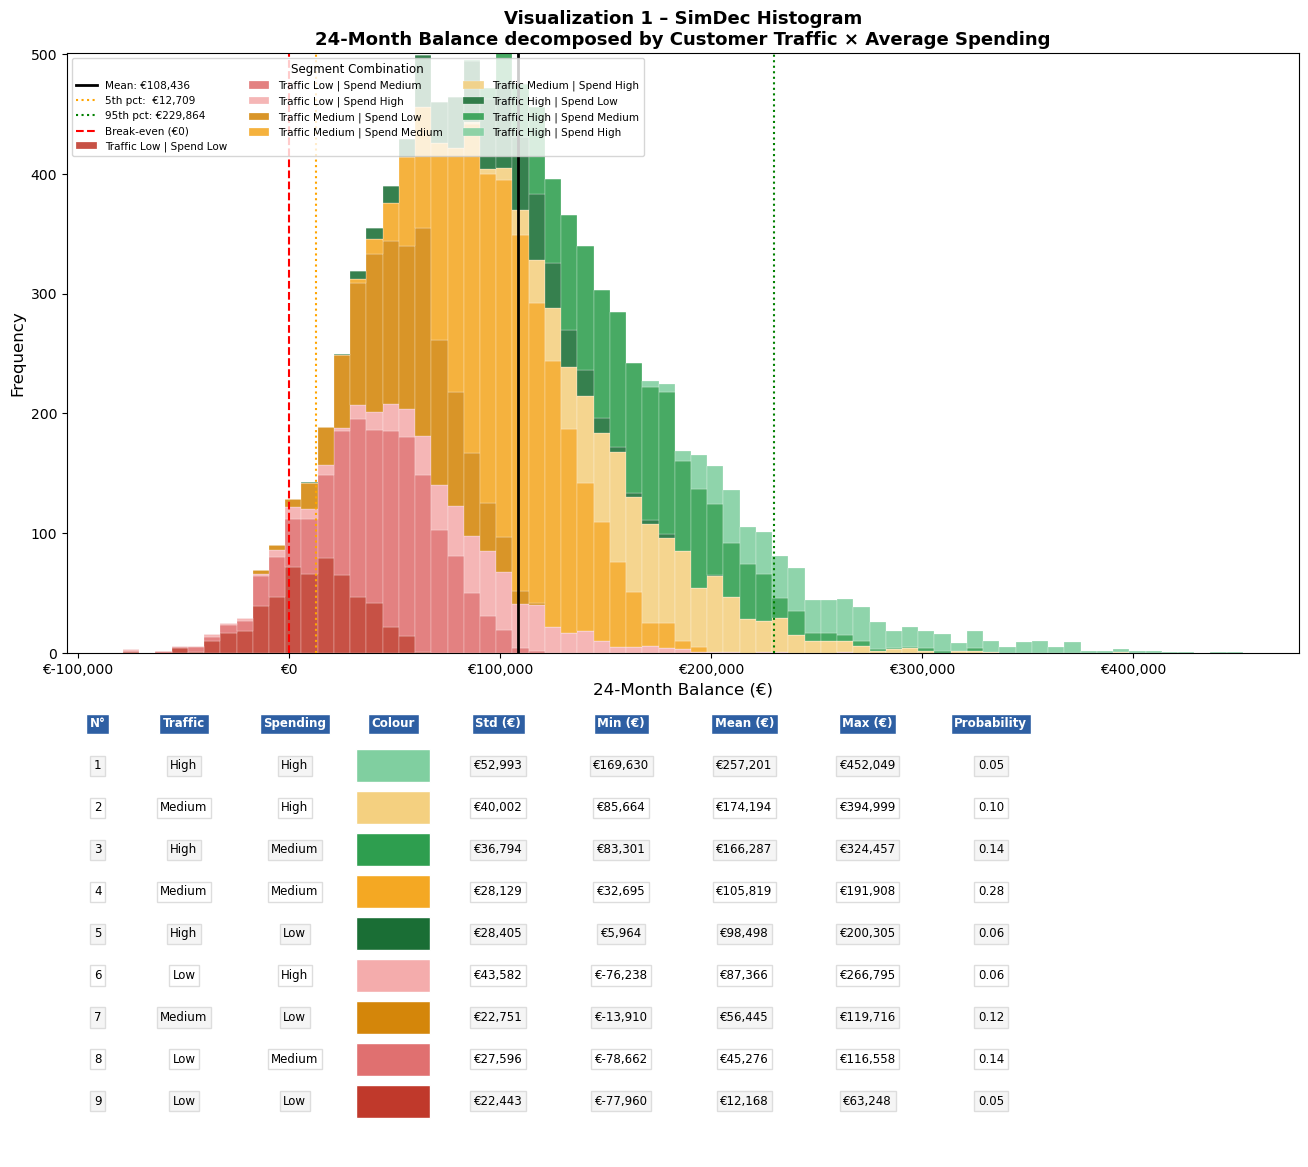

Saved: simdec_histogram.png


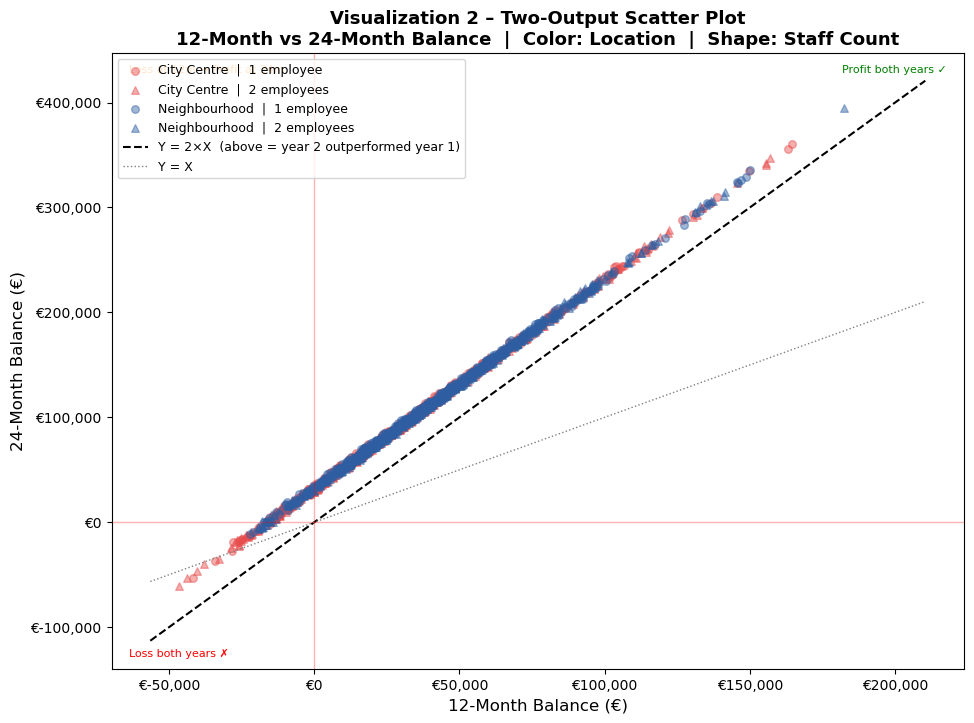

Saved: simdec_scatter.png


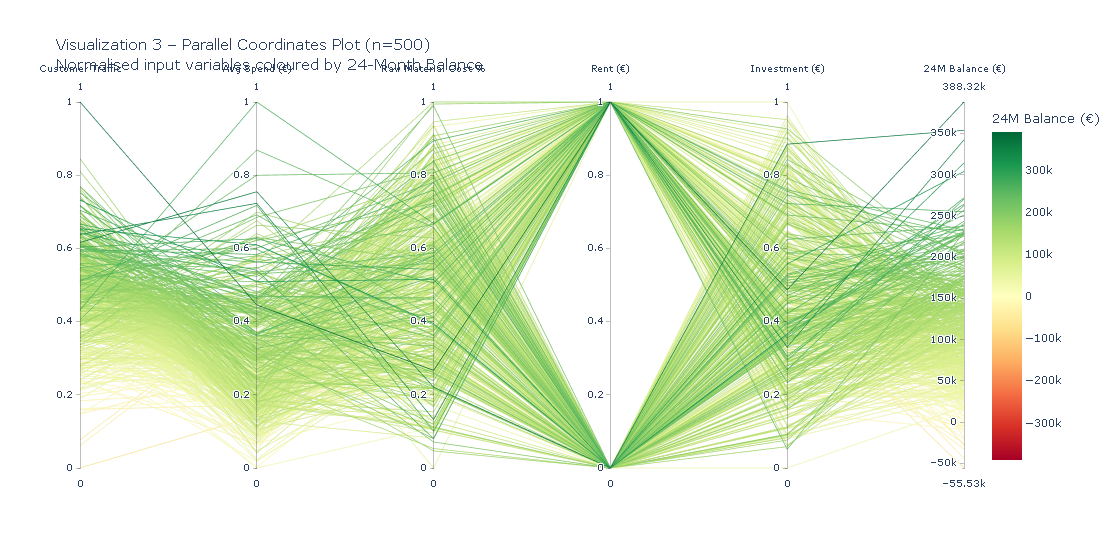

In [17]:
import simdec
import matplotlib.lines as mlines
from itertools import product
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
N = 10_000


# ═════════════════════════════════════════════════════════════════════════════
# CELL 3 – Generate X matrix and Y vector
# ═════════════════════════════════════════════════════════════════════════════

WORKING_DAYS = 24

# Lognormal parameters for average spending (mean=8, std=2)
spending_mean, spending_std = 8, 2
spending_sigma = np.sqrt(np.log(1 + (spending_std / spending_mean) ** 2))
spending_mu    = np.log(spending_mean) - 0.5 * spending_sigma ** 2

# Uncertainty variables
traffic    = np.clip(np.random.normal(55, 15, N), 1, None)
spending   = np.random.lognormal(spending_mu, spending_sigma, N)
raw_cost   = 0.25 + np.random.beta(3, 3, N) * 0.10
investment = np.random.triangular(28000, 32000, 38000, N)

# Decision variables
location_label = np.random.choice(["City Centre", "Neighbourhood"], size=N)
location_rent  = np.where(location_label == "City Centre", 2000, 1050).astype(float)
staff          = np.random.choice([1, 2], size=N)

# Balance formula
def calc_balance(traffic, spending, raw_cost, rent, investment, months):
    monthly_revenue = traffic * spending * WORKING_DAYS
    monthly_costs   = (monthly_revenue * raw_cost) + rent
    return (monthly_revenue - monthly_costs) * months - investment

# Two outputs
Y_12 = calc_balance(traffic, spending, raw_cost, location_rent, investment, 12)
Y_24 = calc_balance(traffic, spending, raw_cost, location_rent, investment, 24)

# X matrix for sensitivity
X          = np.column_stack([traffic, spending, raw_cost, location_rent, investment])
var_names  = ["Customer Traffic", "Avg Spend", "Raw Material Cost",
              "Rent", "Investment"]

print(f"Y_24  — mean: €{Y_24.mean():,.0f} | std: €{Y_24.std():,.0f} | "
      f"P(loss): {(Y_24 < 0).mean():.1%}")
print(f"Y_12  — mean: €{Y_12.mean():,.0f} | std: €{Y_12.std():,.0f} | "
      f"P(loss): {(Y_12 < 0).mean():.1%}")
print(f"X matrix shape: {X.shape}")


# ═════════════════════════════════════════════════════════════════════════════
# CELL 4 – Visualization 1: SimDec Histogram
# Decomposes Y_24 by the two most important variables:
#   Customer Traffic (Sobol rank 1) × Average Spending (Sobol rank 2)
# Produces 9 combination segments + summary table below the histogram
# ═════════════════════════════════════════════════════════════════════════════

# ── Segment both variables into Low / Medium / High ───────────────────────────
traffic_bins = pd.cut(
    pd.Series(traffic),
    bins=[0, 45, 65, pd.Series(traffic).max() + 1],
    labels=["Low", "Medium", "High"]
)

spending_bins = pd.cut(
    pd.Series(spending),
    bins=[0, 6.5, 9.5, pd.Series(spending).max() + 1],
    labels=["Low", "Medium", "High"]
)

# ── 9 combinations: Traffic (L/M/H) × Spending (L/M/H) ───────────────────────
combo_labels = list(product(["Low", "Medium", "High"],    # traffic
                             ["Low", "Medium", "High"]))   # spending

# Colour palette: rows = traffic level, columns = spending level
# Dark = extreme, light = moderate
combo_colors = [
    "#C0392B", "#E07070", "#F4ACAC",   # Traffic Low  × Spend Low / Med / High
    "#D4860A", "#F4A823", "#F4D080",   # Traffic Med  × Spend Low / Med / High
    "#1A6E35", "#2E9E4F", "#80CFA0",   # Traffic High × Spend Low / Med / High
]

# ── Build figure: histogram (top) + table (bottom) ───────────────────────────
bins_edges = np.linspace(Y_24.min(), Y_24.max(), 70)

fig = plt.figure(figsize=(14, 12))
ax_hist  = fig.add_axes([0.08, 0.44, 0.88, 0.50])
ax_table = fig.add_axes([0.08, 0.02, 0.88, 0.38])
ax_table.axis("off")

# ── Stacked histogram ─────────────────────────────────────────────────────────
bottom = np.zeros(len(bins_edges) - 1)
for (t_label, s_label), color in zip(combo_labels, combo_colors):
    mask      = ((traffic_bins == t_label) & (spending_bins == s_label)).values
    counts, _ = np.histogram(Y_24[mask], bins=bins_edges)
    ax_hist.bar(
        bins_edges[:-1], counts, width=np.diff(bins_edges),
        bottom=bottom, color=color, alpha=0.88,
        edgecolor="white", linewidth=0.2,
        label=f"Traffic {t_label} | Spend {s_label}",
        align="edge"
    )
    bottom += counts

# Reference lines
ax_hist.axvline(Y_24.mean(), color="black", lw=2, ls="-",
                label=f"Mean: €{Y_24.mean():,.0f}")
ax_hist.axvline(np.percentile(Y_24,  5), color="orange", lw=1.5, ls=":",
                label=f"5th pct:  €{np.percentile(Y_24, 5):,.0f}")
ax_hist.axvline(np.percentile(Y_24, 95), color="green",  lw=1.5, ls=":",
                label=f"95th pct: €{np.percentile(Y_24,95):,.0f}")
ax_hist.axvline(0, color="red", lw=1.5, ls="--",
                label="Break-even (€0)")

ax_hist.set_xlabel("24-Month Balance (€)", fontsize=12)
ax_hist.set_ylabel("Frequency", fontsize=12)
ax_hist.set_title(
    "Visualization 1 – SimDec Histogram\n"
    "24-Month Balance decomposed by Customer Traffic × Average Spending",
    fontsize=13, fontweight="bold"
)
ax_hist.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
ax_hist.legend(fontsize=7.5, title="Segment Combination",
               title_fontsize=8.5, ncol=3, loc="upper left")

# ── Build and sort table rows ─────────────────────────────────────────────────
table_rows = []
for (t_label, s_label), color in zip(combo_labels, combo_colors):
    mask  = ((traffic_bins == t_label) & (spending_bins == s_label)).values
    seg_Y = Y_24[mask]
    if len(seg_Y) == 0:
        continue
    table_rows.append({
        "t_label": t_label,
        "s_label": s_label,
        "color":   color,
        "n":       int(mask.sum()),
        "std":     seg_Y.std(),
        "min":     seg_Y.min(),
        "mean":    seg_Y.mean(),
        "max":     seg_Y.max(),
        "prob":    mask.sum() / N,
    })

# Sort by mean balance descending (best outcome at top — matches SimDec style)
table_rows.sort(key=lambda x: x["mean"], reverse=True)

# ── Draw table ────────────────────────────────────────────────────────────────
col_labels = ["N°", "Traffic", "Spending", "Colour",
              "Std (€)", "Min (€)", "Mean (€)", "Max (€)", "Probability"]
col_widths = [0.05, 0.09, 0.09, 0.07,
              0.10,  0.10,  0.10,  0.10,  0.10]
row_height = 0.092
header_y   = 0.95

# Header row
for j, (col, w) in enumerate(zip(col_labels, col_widths)):
    x_pos = sum(col_widths[:j])
    ax_table.text(
        x_pos + w / 2, header_y, col,
        ha="center", va="center", fontsize=8.5, fontweight="bold",
        bbox=dict(boxstyle="square,pad=0.3",
                  facecolor="#2E5FA3", edgecolor="white"),
        color="white"
    )

# Data rows
for i, row in enumerate(table_rows):
    y_pos  = header_y - (i + 1) * row_height
    bg_col = "#F5F5F5" if i % 2 == 0 else "white"

    cells = [
        str(i + 1),
        row["t_label"],
        row["s_label"],
        "",                              # colour swatch
        f"€{row['std']:,.0f}",
        f"€{row['min']:,.0f}",
        f"€{row['mean']:,.0f}",
        f"€{row['max']:,.0f}",
        f"{row['prob']:.2f}",
    ]

    for j, (cell, w) in enumerate(zip(cells, col_widths)):
        x_pos = sum(col_widths[:j])
        if j == 3:
            # Colour swatch
            ax_table.add_patch(plt.Rectangle(
                (x_pos + 0.005, y_pos - 0.036), w - 0.01, 0.072,
                facecolor=row["color"], edgecolor="white",
                transform=ax_table.transAxes
            ))
        else:
            ax_table.text(
                x_pos + w / 2, y_pos, cell,
                ha="center", va="center", fontsize=8.5,
                bbox=dict(boxstyle="square,pad=0.3",
                          facecolor=bg_col, edgecolor="#DDDDDD")
            )

ax_table.set_xlim(0, 1)
ax_table.set_ylim(0, 1)

plt.savefig("simdec_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: simdec_histogram.png")


# ═════════════════════════════════════════════════════════════════════════════
# CELL 5 – Visualization 2: Two-output scatter plot
# X-axis: 12-month balance
# Y-axis: 24-month balance
# Color:  Location (City Centre / Neighbourhood)
# Shape:  Staff count (1 / 2 employees)
# ═════════════════════════════════════════════════════════════════════════════

# Subsample 2,000 points for visual clarity
idx = np.random.choice(N, 2000, replace=False)

color_map  = {"City Centre":   "#E84C4C",
              "Neighbourhood": "#2E5FA3"}
marker_map = {1: "o", 2: "^"}
label_map  = {1: "1 employee", 2: "2 employees"}

fig, ax = plt.subplots(figsize=(11, 8))

for loc in ["City Centre", "Neighbourhood"]:
    for st in [1, 2]:
        mask = (location_label[idx] == loc) & (staff[idx] == st)
        ax.scatter(
            Y_12[idx][mask],
            Y_24[idx][mask],
            color=color_map[loc],
            marker=marker_map[st],
            alpha=0.45, s=30,
            label=f"{loc}  |  {label_map[st]}"
        )

# Y = 2X reference line
# Points ABOVE this line: year 2 outperformed year 1
x_range = np.linspace(Y_12.min(), Y_12.max(), 300)
ax.plot(x_range, 2 * x_range, color="black", lw=1.5, ls="--",
        label="Y = 2×X  (above = year 2 outperformed year 1)")

# Y = X line
ax.plot(x_range, x_range, color="grey", lw=1, ls=":",
        label="Y = X")

# Break-even lines
ax.axhline(0, color="red", lw=1, ls="-", alpha=0.3)
ax.axvline(0, color="red", lw=1, ls="-", alpha=0.3)

ax.set_xlabel("12-Month Balance (€)", fontsize=12)
ax.set_ylabel("24-Month Balance (€)", fontsize=12)
ax.set_title(
    "Visualization 2 – Two-Output Scatter Plot\n"
    "12-Month vs 24-Month Balance  |  Color: Location  |  Shape: Staff Count",
    fontsize=13, fontweight="bold"
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
ax.legend(fontsize=9, loc="upper left")

# Quadrant labels
ax.text(0.02, 0.98, "Loss at 12m → Profit at 24m",
        transform=ax.transAxes, va="top", fontsize=8, color="darkorange")
ax.text(0.98, 0.98, "Profit both years ✓",
        transform=ax.transAxes, ha="right", va="top", fontsize=8, color="green")
ax.text(0.02, 0.02, "Loss both years ✗",
        transform=ax.transAxes, fontsize=8, color="red")

plt.savefig("simdec_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: simdec_scatter.png")


# ═════════════════════════════════════════════════════════════════════════════
# CELL 6 – Visualization 3 (Optional): Parallel Coordinates Plot
# ═════════════════════════════════════════════════════════════════════════════

import plotly.express as px

# Sample 500 rows
idx500 = np.random.choice(N, 500, replace=False)

df_parallel = pd.DataFrame({
    "Customer Traffic":    traffic[idx500],
    "Avg Spend (€)":       spending[idx500],
    "Raw Material Cost %": raw_cost[idx500] * 100,
    "Rent (€)":            location_rent[idx500],
    "Investment (€)":      investment[idx500],
    "24M Balance (€)":     Y_24[idx500],
})

# Normalise input columns to [0, 1] for visual comparability
input_cols = ["Customer Traffic", "Avg Spend (€)", "Raw Material Cost %",
              "Rent (€)", "Investment (€)"]
df_norm = df_parallel.copy()
for col in input_cols:
    col_min = df_parallel[col].min()
    col_max = df_parallel[col].max()
    df_norm[col] = (df_parallel[col] - col_min) / (col_max - col_min)

fig_px = px.parallel_coordinates(
    df_norm,
    dimensions=input_cols + ["24M Balance (€)"],
    color="24M Balance (€)",
    color_continuous_scale=px.colors.diverging.RdYlGn,
    color_continuous_midpoint=0,
    title="Visualization 3 – Parallel Coordinates Plot (n=500)<br>"
          "Normalised input variables coloured by 24-Month Balance"
)
fig_px.update_layout(font=dict(size=11), height=550)
fig_px.show()